In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

import joblib

In [53]:
# =============================
# 2. Load Dataset
# =============================

df = pd.read_csv("dataset/Symptoms_Dataset.csv")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (18069, 9)
                     Symptoms  Age     Sex Disease    Treatment Nature  \
0                   coughing   5.0  female  Asthma   Omalizumab   high   
1  tight feeling in the chest  4.0  female  Asthma  Mepolizumab   high   
2                    wheezing  6.0    male  Asthma  Mepolizumab   high   
3         shortness of breath  7.0    male  Asthma  Mepolizumab   high   
4         shortness of breath  9.0    male  Asthma  Mepolizumab   high   

   Unnamed: 6  Unnamed: 7  Unnamed: 8  
0         NaN         NaN         NaN  
1         NaN         NaN         NaN  
2         NaN         NaN         NaN  
3         NaN         NaN         NaN  
4         NaN         NaN         NaN  


In [54]:
df['Symptoms'] =(df['Symptoms'].astype(str)
                            .str.strip()
                            .str.lower())

In [55]:
df['Symptoms'].value_counts()

Symptoms
wheezing                           1869
shortness of breath                1716
fatigue                            1344
chest pain                         1200
mucus                              1152
yellow cough                       1118
chronic cough                       864
cold                                845
low-grade fever                     685
nausea                              672
feeling run-down or tired           624
whistling sound while breathing     538
runny nose                          535
stuffy nose                         489
fever                               461
chest congestion                    440
greenish cough                      336
cough with blood                    336
sweating                            336
shaking                             336
rapid breathing                     336
shallow breathing                   336
low energy                          336
loss of appetite                    336
vomiting                       

In [57]:
# =============================
# 3. Data Cleaning
# =============================

# Drop useless columns
for col in df.columns:
    if "Unnamed" in col:
        df.drop(columns=col, inplace=True)

df.drop(columns=['Treatment','Nature'],inplace= True)

In [60]:
df.isnull().sum()

Symptoms    0
Age         0
Sex         0
Disease     0
dtype: int64

In [59]:
# Handle missing values


# 1. Drop rows where Symptoms is NaN (Correct way)
df = df.dropna(subset=['Symptoms'])

# 2. Fill numeric and categorical (Your logic is correct here)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex'] = df['Sex'].fillna(df['Sex'].mode()[0])


In [61]:
def clean_disease(x):
    x = str(x).lower().strip()
    if "bronchitis" in x:
        return "Bronchitis"
    elif "pneumonia" in x:
        return "Pneumonia"
    elif "asthma" in x:
        return "Asthma"
    elif "copd" in x:
        return "COPD"
    else:
        return x.title()


df['Disease'] = df['Disease'].apply(clean_disease)

print(df['Disease'].value_counts())

Disease
Bronchitis                               6941
Pneumonia                                6048
Chronic Obstructive Pulmonary Disease    3888
Asthma                                   1048
Name: count, dtype: int64


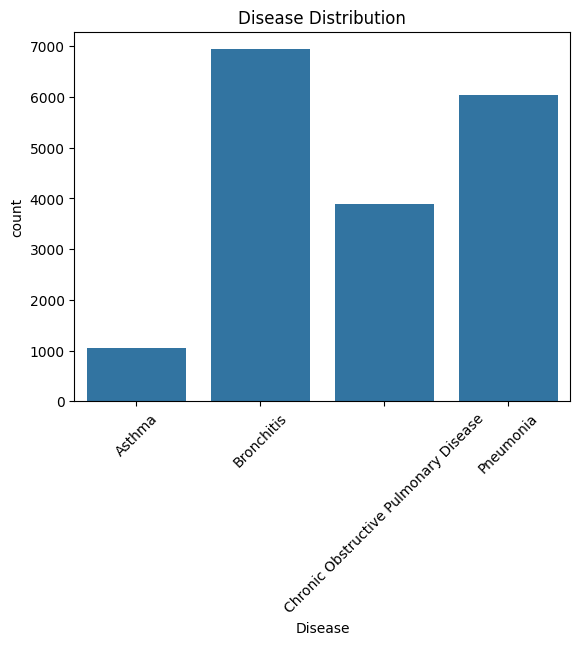

In [62]:
# =============================
# 4. EDA (Exploratory Data Analysis)
# =============================

# Class distribution
plt.figure()
sns.countplot(x=df['Disease'])
plt.title("Disease Distribution")
plt.xticks(rotation=45)
plt.show()

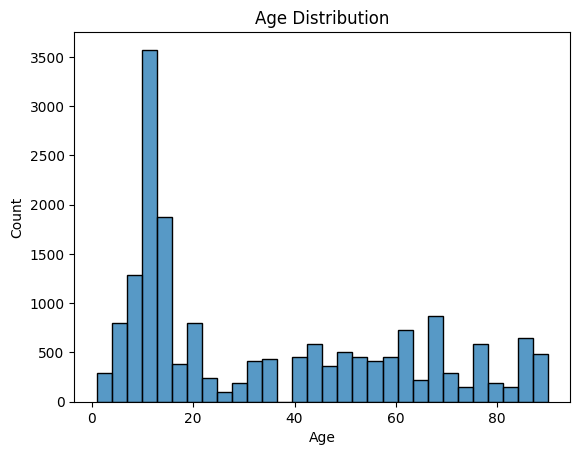

In [63]:
# Age distribution
plt.figure()
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

In [64]:
# =============================
# 5. Feature & Target Split
# =============================

X = df[['Symptoms', 'Age', 'Sex']]
y = df['Disease']


In [65]:
# =============================
# 6. Train Test Split
# =============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [66]:
# =============================
# 7. Preprocessing Pipeline
# =============================

text_features = 'Symptoms'
numeric_features = ['Age']
categorical_features = ['Sex']

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=5000), text_features),
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [67]:
# =============================
# 8. Model
# =============================

model = RandomForestClassifier(n_estimators=200, random_state=42)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", model)
])

In [68]:
# =============================
# 9. Handle Class Imbalance
# =============================

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

pipeline.named_steps['classifier'].set_params(class_weight=class_weights)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [69]:
# =============================
# 10. Training
# =============================

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [70]:
# =============================
# 11. Evaluation
# =============================

# Predictions
y_pred = pipeline.predict(X_test)

In [71]:
# Classification report
print(classification_report(y_test, y_pred))

                                       precision    recall  f1-score   support

                               Asthma       0.83      1.00      0.91       210
                           Bronchitis       0.99      0.93      0.96      1388
Chronic Obstructive Pulmonary Disease       0.89      0.97      0.93       778
                            Pneumonia       0.98      0.96      0.97      1209

                             accuracy                           0.95      3585
                            macro avg       0.92      0.96      0.94      3585
                         weighted avg       0.95      0.95      0.95      3585



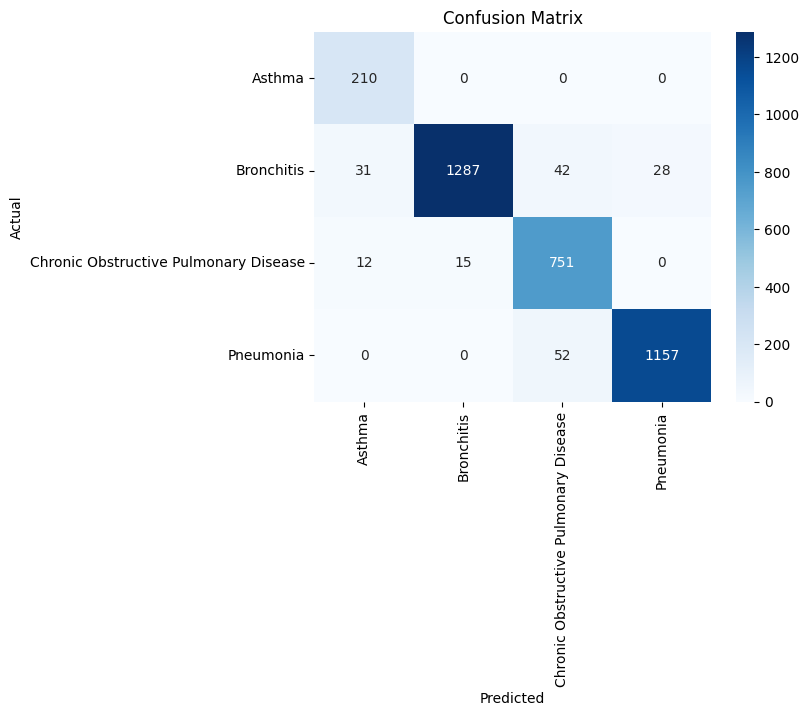

In [72]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [73]:
# =============================
# Cross Validation
# =============================

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline, 
    X, 
    y, 
    cv=kfold, 
    scoring='accuracy',
    n_jobs=-1
)

print("Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.9553696  0.95034868 0.95481172 0.9511855  0.95341702]
Mean Accuracy: 0.9530264993026499
Standard Deviation: 0.001969245477793313


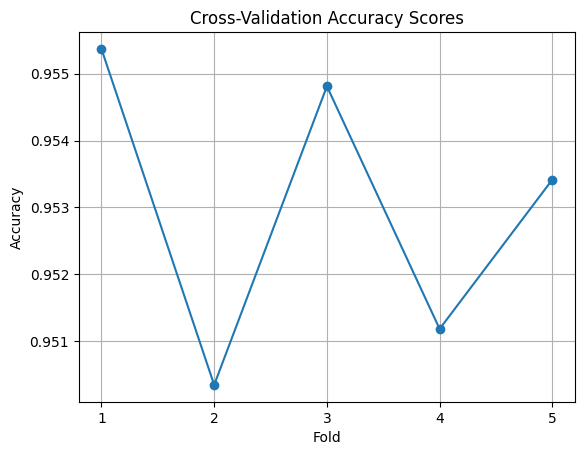

In [74]:
plt.figure()
plt.plot(range(1, 6), cv_scores, marker='o')
plt.title("Cross-Validation Accuracy Scores")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.grid()
plt.show()

In [75]:
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=kfold,
    scoring=scoring,
    n_jobs=-1
)

print("Accuracy:", cv_results['test_accuracy'].mean())
print("Precision:", cv_results['test_precision_weighted'].mean())
print("Recall:", cv_results['test_recall_weighted'].mean())
print("F1 Score:", cv_results['test_f1_weighted'].mean())

Accuracy: 0.9530264993026499
Precision: 0.9566631794425913
Recall: 0.9530264993026499
F1 Score: 0.9535517435630453


In [76]:
# =============================
# 12. Save Model
# =============================

joblib.dump(pipeline, "symptoms_model_pipeline.pkl")
print("Model saved successfully!")

# =============================
# 13. Prediction Function (Deployment Ready)
# =============================

def predict_disease(symptoms, age, sex):
    model = joblib.load("symptoms_model_pipeline.pkl")
    input_df = pd.DataFrame({
        'Symptoms': [symptoms],
        'Age': [age],
        'Sex': [sex]
    })
    prediction = model.predict(input_df)[0]
    probs = model.predict_proba(input_df)
    return prediction, probs

# Example
pred, prob = predict_disease("cough fever chest pain", 45, "Male")
print("Prediction:", pred)

Model saved successfully!
Prediction: Pneumonia
